# Rutgers Dining Hall Menu & Nutrition Analysis
CS 210: Data Management for Data Science -- Final Project

This notebook turns the raw `output.json` produced by `NutritionScrape.ipynb` into:

1. a flat, cleaned DataFrame and CSV,
2. a normalized SQLite database with five tables,
3. analytical SQL queries answering nutrition questions about Rutgers dining halls,
4. visualizations summarizing the dataset, and
5. a rule-based recommendation system that ranks foods by student-defined goals
   (high protein, low calorie, low sodium, balanced).


## 1. Imports & configuration

In [33]:
import json
import re
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

DATA_DIR  = Path("data")
DATA_DIR.mkdir(exist_ok=True)

RAW_JSON  = Path("output.json")          # produced by NutritionScrape.ipynb
FLAT_CSV  = DATA_DIR / "menu_items_flat.csv"
DB_PATH   = DATA_DIR / "dining.db"


## 2. Load the raw scraped JSON

`NutritionScrape.ipynb` writes a nested structure: `halls -> meals -> items`, plus a
top-level `scrape_date` / `scrape_timestamp`. We load it as-is here.


In [34]:
with open(RAW_JSON, "r", encoding="utf-8") as f:
    raw = json.load(f)

print("scrape_date     :", raw["scrape_date"])
print("scrape_timestamp:", raw["scrape_timestamp"])
print("halls           :", list(raw["halls"].keys()))


scrape_date     : 05/07/2026
scrape_timestamp: 2026-05-07T18:01:57
halls           : ['Livingston', 'Neilson', 'The Atrium']


## 3. Flatten the nested JSON into a single DataFrame

Each row will represent one (hall, meal, item) combination. Numeric
nutrition values are parsed out of the scraped strings such as
`"12 g"`, `"230 mg"`, or `"180 kcal"`.


In [35]:
# Regex that pulls a number (possibly decimal) from strings like "12 g" or "230 mg"
_NUM_RE = re.compile(r"-?\d+(?:\.\d+)?")

def parse_amount(value):
    """Return float for the numeric portion of a nutrition string."""
    if value is None:
        return np.nan
    s = str(value).strip()
    if not s:
        return np.nan
    m = _NUM_RE.search(s)
    return float(m.group()) if m else np.nan


# Map raw nutrition keys -> canonical column names + expected unit.
NUTRIENT_MAP = {
    "Calories":           ("calories_kcal",  None),
    "Total Fat":          ("total_fat_g",    "g"),
    "Sat. Fat":           ("sat_fat_g",      "g"),
    "Trans Fat":          ("trans_fat_g",    "g"),
    "Cholesterol":        ("cholesterol_mg", "mg"),
    "Sodium":             ("sodium_mg",      "mg"),
    "Total Carbohydrate": ("total_carbs_g",  "g"),
    "Dietary Fiber":      ("fiber_g",        "g"),
    "Sugars":             ("sugar_g",        "g"),
    "Protein":            ("protein_g",      "g"),
}


def flatten(raw):
    rows = []
    scrape_date = raw.get("scrape_date")
    scrape_ts   = raw.get("scrape_timestamp")
    for hall_name, hall_block in raw["halls"].items():
        campus = hall_block.get("campus")
        for meal_name, meal_block in hall_block["meals"].items():
            source_url = meal_block.get("source_url")
            for item in meal_block["items"]:
                nut = item.get("nutrition") or {}
                row = {
                    "scrape_date":      scrape_date,
                    "scrape_timestamp": scrape_ts,
                    "dining_hall":      hall_name,
                    "campus":           campus,
                    "meal_period":      meal_name,
                    "item_name":        item.get("item_name"),
                    "serving_size":     item.get("serving_size"),
                    "source_url":       source_url,
                    "nutrition_link":   item.get("nutrition_link"),
                }
                for raw_key, (col, _unit) in NUTRIENT_MAP.items():
                    row[col] = parse_amount(nut.get(raw_key))
                rows.append(row)
    return pd.DataFrame(rows)


df = flatten(raw)
print(f"Loaded {len(df):,} rows  /  {df['dining_hall'].nunique()} halls  /  {df['meal_period'].nunique()} meals")
df.head()


Loaded 608 rows  /  3 halls  /  3 meals


,scrape_date,scrape_timestamp,dining_hall,campus,meal_period,item_name,serving_size,source_url,nutrition_link,calories_kcal,total_fat_g,sat_fat_g,trans_fat_g,cholesterol_mg,sodium_mg,total_carbs_g,fiber_g,sugar_g,protein_g
0,05/07/2026,2026-05-07T18:01:57,Livingston,Livingston,Lunch,BEEF FAJITA SOUP,4 OZ,https://menuportal23.dining.rutgers.edu/FoodPr...,https://menuportal23.dining.rutgers.edu/FoodPr...,108.0,2.6,0.9,0.0,28.3,242.5,NaN,1.5,1.5,12.8
1,05/07/2026,2026-05-07T18:01:57,Livingston,Livingston,Lunch,CHEESE AND BROCCOLI SOUP,6 OZ,https://menuportal23.dining.rutgers.edu/FoodPr...,https://menuportal23.dining.rutgers.edu/FoodPr...,152.0,7.2,4.0,0.0,17.4,521.0,NaN,1.8,3.7,7.0
2,05/07/2026,2026-05-07T18:01:57,Livingston,Livingston,Lunch,BLACK BEAN BURGER,1 EACH,https://menuportal23.dining.rutgers.edu/FoodPr...,https://menuportal23.dining.rutgers.edu/FoodPr...,146.0,6.7,0.0,0.0,0.0,416.1,NaN,3.5,0.0,6.2
3,05/07/2026,2026-05-07T18:01:57,Livingston,Livingston,Lunch,BREADED CHICKEN CUTLET,1 EACH,https://menuportal23.dining.rutgers.edu/FoodPr...,https://menuportal23.dining.rutgers.edu/FoodPr...,273.0,10.1,2.0,0.0,65.8,688.5,NaN,1.0,0.0,26.3
4,05/07/2026,2026-05-07T18:01:57,Livingston,Livingston,Lunch,GRILLED HOT DOGS,1 EACH,https://menuportal23.dining.rutgers.edu/FoodPr...,https://menuportal23.dining.rutgers.edu/FoodPr...,239.0,22.5,6.6,0.7,19.9,530.5,NaN,0.0,0.0,9.3


## 4. Cleaning

Steps:

* drop rows with no `item_name`,
* strip whitespace and standardize casing on `item_name`,
* drop exact duplicates within a (hall, meal, item) group,
* validate numeric fields -- impossible values (negative, calories > 5000)
  become `NaN` rather than being dropped, so we keep the row context,
* derive simple dietary-label heuristics from the item name.


In [36]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ---- text cleanup --------------------------------------------------
    df["item_name"] = (df["item_name"]
                       .astype(str)
                       .str.replace(r"\s+", " ", regex=True)
                       .str.strip())
    df = df[df["item_name"].str.len() > 0]

    # ---- duplicates ----------------------------------------------------
    before = len(df)
    df = df.drop_duplicates(subset=["dining_hall", "meal_period", "item_name"])
    print(f"Dropped {before - len(df)} exact duplicate rows.")

    # ---- numeric validation -------------------------------------------
    numeric_cols = [c for c in df.columns if c.endswith(("_g", "_mg", "_kcal"))]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        # impossible values -> NaN (don't drop -- keep item context)
        df.loc[df[c] < 0, c] = np.nan
    df.loc[df["calories_kcal"] > 5000, "calories_kcal"] = np.nan
    df.loc[df["sodium_mg"]   > 8000, "sodium_mg"]   = np.nan
    df.loc[df["protein_g"]   > 200,  "protein_g"]   = np.nan
    df.loc[df["total_fat_g"] > 300,  "total_fat_g"] = np.nan

    # ---- labels from item name ----------------------------
    name_lc = df["item_name"].str.lower()
    meat_terms = (r"chicken|beef|pork|bacon|sausage|turkey|ham|"
                  r"lamb|shrimp|tuna|salmon|fish|anchovy|pepperoni")
    df["is_vegetarian"] = ~name_lc.str.contains(meat_terms, regex=True, na=False)
    df["is_vegan"]      = (df["is_vegetarian"]
                            & ~name_lc.str.contains(r"cheese|milk|butter|cream|egg|yogurt|whey",
                                                    regex=True, na=False))
    df["is_high_protein"] = df["protein_g"] >= 20
    df["is_low_calorie"]  = df["calories_kcal"] < 400
    df["is_low_sodium"]   = df["sodium_mg"] < 600

    return df.reset_index(drop=True)


clean_df = clean(df)
print(f"After cleaning: {len(clean_df):,} rows")
clean_df.describe(include="all").T.head(15)


Dropped 33 exact duplicate rows.
After cleaning: 575 rows


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
scrape_date,575,1,05/07/2026,575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_timestamp,575,1,2026-05-07T18:01:57,575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dining_hall,575,3,The Atrium,291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campus,575,3,Busch,291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
meal_period,575,3,Lunch,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_name,575,261,AVOCADO MASH,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
serving_size,575,36,4 OZ,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_url,575,8,https://menuportal23.dining.rutgers.edu/FoodPr...,130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nutrition_link,575,313,https://menuportal23.dining.rutgers.edu/FoodPr...,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calories_kcal,574.0,NaN,NaN,NaN,172.219512,188.084421,0.0,56.0,124.0,210.0,1405.0


### Completeness check

How often are nutrition fields actually present? Missingness is not a
bug -- some menu items lack nutrition pages -- but it tells us how
trustworthy each downstream metric is.


In [37]:
nutri_cols = ["calories_kcal", "total_fat_g", "sat_fat_g", "sodium_mg",
              "total_carbs_g", "fiber_g", "sugar_g", "protein_g"]
completeness = (clean_df[nutri_cols]
                .notna()
                .mean()
                .mul(100)
                .round(1)
                .rename("pct_present"))
completeness.to_frame()


,pct_present
calories_kcal,99.8
total_fat_g,99.8
sat_fat_g,98.8
sodium_mg,99.7
total_carbs_g,0.0
fiber_g,97.9
sugar_g,96.9
protein_g,99.8


## 5. Save the flat cleaned CSV

In [38]:
clean_df.to_csv(FLAT_CSV, index=False)
print(f"Wrote {FLAT_CSV}  ({FLAT_CSV.stat().st_size / 1024:.1f} KB)")


Wrote data/menu_items_flat.csv  (269.2 KB)


## 6. Build the SQLite database

We normalize into five tables, matching the proposal:

* **dining_halls** (`hall_id`, `hall_name`, `campus`, `location_num`)
* **scrape_runs** (`run_id`, `scrape_date`, `scrape_timestamp`, `total_items`)
* **menu_items** (`item_id`, `run_id` FK, `hall_id` FK, `meal_period`, `item_name`, `serving_size`, `source_url`, `nutrition_link`)
* **nutrition_facts** (`item_id` PK/FK, plus per-nutrient numeric columns)
* **dietary_labels** (`item_id` FK, `label`) -- derived heuristic labels (vegetarian, vegan, high_protein, ...)

This separation keeps the schema sane: identifying info lives in
`menu_items`, numbers live in `nutrition_facts`, and tags live in their own
table so a single item can carry multiple labels.


In [39]:
SCHEMA = """
DROP TABLE IF EXISTS dietary_labels;
DROP TABLE IF EXISTS nutrition_facts;
DROP TABLE IF EXISTS menu_items;
DROP TABLE IF EXISTS scrape_runs;
DROP TABLE IF EXISTS dining_halls;

CREATE TABLE dining_halls (
    hall_id      INTEGER PRIMARY KEY AUTOINCREMENT,
    hall_name    TEXT UNIQUE NOT NULL,
    campus       TEXT,
    location_num TEXT
);

CREATE TABLE scrape_runs (
    run_id           INTEGER PRIMARY KEY AUTOINCREMENT,
    scrape_date      TEXT NOT NULL,
    scrape_timestamp TEXT NOT NULL,
    total_items      INTEGER
);

CREATE TABLE menu_items (
    item_id        INTEGER PRIMARY KEY AUTOINCREMENT,
    run_id         INTEGER NOT NULL REFERENCES scrape_runs(run_id),
    hall_id        INTEGER NOT NULL REFERENCES dining_halls(hall_id),
    meal_period    TEXT NOT NULL,
    item_name      TEXT NOT NULL,
    serving_size   TEXT,
    source_url     TEXT,
    nutrition_link TEXT
);

CREATE TABLE nutrition_facts (
    item_id        INTEGER PRIMARY KEY REFERENCES menu_items(item_id),
    calories_kcal  REAL,
    total_fat_g    REAL,
    sat_fat_g      REAL,
    trans_fat_g    REAL,
    cholesterol_mg REAL,
    sodium_mg      REAL,
    total_carbs_g  REAL,
    fiber_g        REAL,
    sugar_g        REAL,
    protein_g      REAL
);

CREATE TABLE dietary_labels (
    item_id INTEGER NOT NULL REFERENCES menu_items(item_id),
    label   TEXT NOT NULL,
    PRIMARY KEY (item_id, label)
);

CREATE INDEX idx_items_hall  ON menu_items(hall_id);
CREATE INDEX idx_items_meal  ON menu_items(meal_period);
CREATE INDEX idx_labels_lbl  ON dietary_labels(label);
"""

con = sqlite3.connect(DB_PATH)
con.executescript(SCHEMA)
con.commit()
print("Schema created at", DB_PATH)


Schema created at data/dining.db


### Load the cleaned DataFrame into the database

In [40]:
def load_db(con: sqlite3.Connection, df: pd.DataFrame, raw_meta: dict):
    cur = con.cursor()

    # 1. dining_halls
    halls = df[["dining_hall", "campus"]].drop_duplicates().reset_index(drop=True)
    location_map = {"Livingston": "03", "Neilson": "05", "The Atrium": "13"}
    for _, row in halls.iterrows():
        cur.execute(
            "INSERT INTO dining_halls (hall_name, campus, location_num) VALUES (?, ?, ?)",
            (row["dining_hall"], row["campus"], location_map.get(row["dining_hall"])),
        )

    # 2. scrape_runs (one run per notebook execution)
    cur.execute(
        "INSERT INTO scrape_runs (scrape_date, scrape_timestamp, total_items) VALUES (?, ?, ?)",
        (raw_meta["scrape_date"], raw_meta["scrape_timestamp"], len(df)),
    )
    run_id = cur.lastrowid

    # lookup table for hall_id
    hall_id_lookup = dict(cur.execute("SELECT hall_name, hall_id FROM dining_halls").fetchall())

    # 3. menu_items + 4. nutrition_facts + 5. dietary_labels
    label_cols = ["is_vegetarian", "is_vegan", "is_high_protein", "is_low_calorie", "is_low_sodium"]
    for _, row in df.iterrows():
        cur.execute(
            """INSERT INTO menu_items
                 (run_id, hall_id, meal_period, item_name, serving_size,
                  source_url, nutrition_link)
                 VALUES (?, ?, ?, ?, ?, ?, ?)""",
            (run_id, hall_id_lookup[row["dining_hall"]], row["meal_period"],
             row["item_name"], row["serving_size"],
             row["source_url"], row["nutrition_link"]),
        )
        item_id = cur.lastrowid

        cur.execute(
            """INSERT INTO nutrition_facts
                 (item_id, calories_kcal, total_fat_g, sat_fat_g, trans_fat_g,
                  cholesterol_mg, sodium_mg, total_carbs_g, fiber_g, sugar_g, protein_g)
                 VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)""",
            (item_id, row.get("calories_kcal"), row.get("total_fat_g"),
             row.get("sat_fat_g"), row.get("trans_fat_g"),
             row.get("cholesterol_mg"), row.get("sodium_mg"),
             row.get("total_carbs_g"), row.get("fiber_g"),
             row.get("sugar_g"), row.get("protein_g")),
        )

        for col in label_cols:
            if bool(row.get(col, False)):
                cur.execute(
                    "INSERT OR IGNORE INTO dietary_labels (item_id, label) VALUES (?, ?)",
                    (item_id, col.replace("is_", "")),
                )

    con.commit()


load_db(con, clean_df, raw)
# quick row counts
for tbl in ["dining_halls", "scrape_runs", "menu_items", "nutrition_facts", "dietary_labels"]:
    n = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    print(f"{tbl:<20s} {n:>6,}")


dining_halls              3
scrape_runs               1
menu_items              575
nutrition_facts         575
dietary_labels        1,900


## 7. Analysis: SQL queries

All of the questions below come from the proposal's evaluation plan.
Each is run as a SQL query against the SQLite DB so we exercise the
relational schema we just built.


### 7.1 Average calories per dining hall

In [41]:
q = """
SELECT h.hall_name,
       ROUND(AVG(n.calories_kcal), 1) AS avg_calories,
       COUNT(*)                       AS items_with_calories
  FROM menu_items     m
  JOIN dining_halls   h ON m.hall_id = h.hall_id
  JOIN nutrition_facts n ON m.item_id = n.item_id
 WHERE n.calories_kcal IS NOT NULL
 GROUP BY h.hall_name
 ORDER BY avg_calories DESC;
"""
avg_cal_by_hall = pd.read_sql_query(q, con)
avg_cal_by_hall


,hall_name,avg_calories,items_with_calories
0,The Atrium,202.1,291
1,Neilson,147.1,154
2,Livingston,134.9,129


### 7.2 Average protein per dining hall

In [42]:
q = """
SELECT h.hall_name,
       ROUND(AVG(n.protein_g), 1) AS avg_protein_g,
       COUNT(*)                   AS items_with_protein
  FROM menu_items     m
  JOIN dining_halls   h ON m.hall_id = h.hall_id
  JOIN nutrition_facts n ON m.item_id = n.item_id
 WHERE n.protein_g IS NOT NULL
 GROUP BY h.hall_name
 ORDER BY avg_protein_g DESC;
"""
avg_prot_by_hall = pd.read_sql_query(q, con)
avg_prot_by_hall


,hall_name,avg_protein_g,items_with_protein
0,The Atrium,9.8,291
1,Neilson,7.7,154
2,Livingston,6.6,129


### 7.3 Top 15 high-protein items overall

In [43]:
q = """
SELECT h.hall_name,
       m.meal_period,
       m.item_name,
       n.protein_g,
       n.calories_kcal
  FROM menu_items     m
  JOIN dining_halls   h ON m.hall_id = h.hall_id
  JOIN nutrition_facts n ON m.item_id = n.item_id
 WHERE n.protein_g IS NOT NULL
 ORDER BY n.protein_g DESC
 LIMIT 15;
"""
top_protein = pd.read_sql_query(q, con)
top_protein


,hall_name,meal_period,item_name,protein_g,calories_kcal
0,Neilson,Lunch,ROTISSERIE STYLE CHICKEN,63.4,421.0
1,Neilson,Dinner,ROTISSERIE STYLE CHICKEN,63.4,421.0
2,The Atrium,Lunch,MACARONI AND CHEESE W. CHICKEN TENDERS,62.8,1405.0
3,The Atrium,Dinner,MACARONI AND CHEESE W. CHICKEN TENDERS,62.8,1405.0
4,The Atrium,Lunch,SCARLET HOT CRISPY CHICKEN SANDWICH,61.5,773.0
5,The Atrium,Dinner,SCARLET HOT CRISPY CHICKEN SANDWICH,61.5,773.0
6,The Atrium,Lunch,SCARLET HOT GRILLED CHICKEN SANDWICH,59.6,510.0
7,The Atrium,Dinner,SCARLET HOT GRILLED CHICKEN SANDWICH,59.6,510.0
8,The Atrium,Lunch,CHICKEN SOUVLAKI,58.0,320.0
9,The Atrium,Dinner,CHICKEN SOUVLAKI,58.0,320.0


### 7.4 High-protein options under 600 calories

In [44]:
q = """
SELECT h.hall_name,
       m.meal_period,
       m.item_name,
       n.protein_g,
       n.calories_kcal,
       ROUND(n.protein_g * 1.0 / n.calories_kcal, 3) AS protein_per_kcal
  FROM menu_items     m
  JOIN dining_halls   h ON m.hall_id = h.hall_id
  JOIN nutrition_facts n ON m.item_id = n.item_id
 WHERE n.protein_g    >= 20
   AND n.calories_kcal <  600
   AND n.calories_kcal IS NOT NULL
 ORDER BY protein_per_kcal DESC
 LIMIT 20;
"""
hp_lc = pd.read_sql_query(q, con)
hp_lc


,hall_name,meal_period,item_name,protein_g,calories_kcal,protein_per_kcal
0,The Atrium,Lunch,GRILLED CHICKEN BREAST,25.3,131.0,0.193
1,The Atrium,Dinner,GRILLED CHICKEN BREAST,25.3,131.0,0.193
2,The Atrium,Lunch,CHICKEN SOUVLAKI,58.0,320.0,0.181
3,The Atrium,Dinner,CHICKEN SOUVLAKI,58.0,320.0,0.181
4,Livingston,Lunch,GRILLED CHICKEN BREAST 4OZ,25.4,142.0,0.179
5,Livingston,Dinner,GRILLED CHICKEN BREAST 4OZ,25.4,142.0,0.179
6,The Atrium,Lunch,BAJA SHRIMP,23.5,134.0,0.175
7,The Atrium,Dinner,BAJA SHRIMP,23.5,134.0,0.175
8,The Atrium,Lunch,GRILLED HALAL CHICKEN,26.3,157.0,0.168
9,The Atrium,Dinner,GRILLED HALAL CHICKEN,26.3,157.0,0.168


### 7.5 Highest sodium items (worth flagging for students)

In [45]:
q = """
SELECT h.hall_name,
       m.meal_period,
       m.item_name,
       n.sodium_mg,
       n.calories_kcal
  FROM menu_items     m
  JOIN dining_halls   h ON m.hall_id = h.hall_id
  JOIN nutrition_facts n ON m.item_id = n.item_id
 WHERE n.sodium_mg IS NOT NULL
 ORDER BY n.sodium_mg DESC
 LIMIT 15;
"""
high_sodium = pd.read_sql_query(q, con)
high_sodium


,hall_name,meal_period,item_name,sodium_mg,calories_kcal
0,The Atrium,Lunch,SCARLET HOT CRISPY CHICKEN SANDWICH,2575.9,773.0
1,The Atrium,Dinner,SCARLET HOT CRISPY CHICKEN SANDWICH,2575.9,773.0
2,Neilson,Lunch,HAM AND SWISS WRAP,1957.6,555.0
3,Neilson,Dinner,HAM AND SWISS WRAP,1957.6,555.0
4,Livingston,Lunch,HONEY THAI CHILI GLAZED CHICKEN WINGS,1752.8,445.0
5,The Atrium,Lunch,MACARONI AND CHEESE W. CHICKEN TENDERS,1728.6,1405.0
6,The Atrium,Dinner,MACARONI AND CHEESE W. CHICKEN TENDERS,1728.6,1405.0
7,The Atrium,Lunch,TERIYAKI SAUCE GLAZE,1661.9,101.0
8,The Atrium,Dinner,TERIYAKI SAUCE GLAZE,1661.9,101.0
9,Neilson,Dinner,VEGAN JAMAICAN SEITAN STEW,1658.1,99.0


### 7.6 Menu variety per hall (distinct items by meal)

In [46]:
q = """
SELECT h.hall_name,
       m.meal_period,
       COUNT(DISTINCT m.item_name) AS distinct_items
  FROM menu_items   m
  JOIN dining_halls h ON m.hall_id = h.hall_id
 GROUP BY h.hall_name, m.meal_period
 ORDER BY h.hall_name, m.meal_period;
"""
variety = pd.read_sql_query(q, con)
variety


,hall_name,meal_period,distinct_items
0,Livingston,Dinner,64
1,Livingston,Lunch,65
2,Neilson,Breakfast,26
3,Neilson,Dinner,64
4,Neilson,Lunch,65
5,The Atrium,Breakfast,31
6,The Atrium,Dinner,130
7,The Atrium,Lunch,130


## 8. Visualizations

Five Matplotlib plots that the demo video can step through.


### 8.1 Average calories per dining hall (bar)

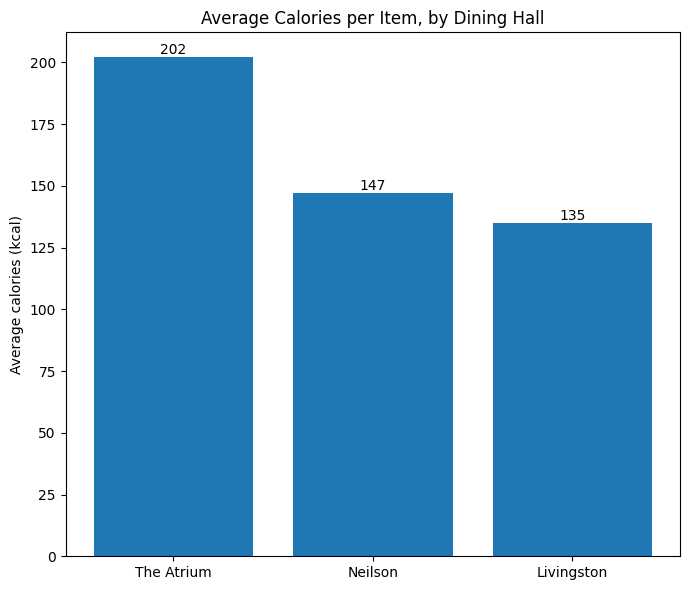

In [47]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(avg_cal_by_hall["hall_name"], avg_cal_by_hall["avg_calories"])
ax.set_ylabel("Average calories (kcal)")
ax.set_title("Average Calories per Item, by Dining Hall")
for i, v in enumerate(avg_cal_by_hall["avg_calories"]):
    ax.text(i, v, f"{v:.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_avg_calories.png", dpi=150)
plt.show()


### 8.2 Average protein per dining hall (bar)

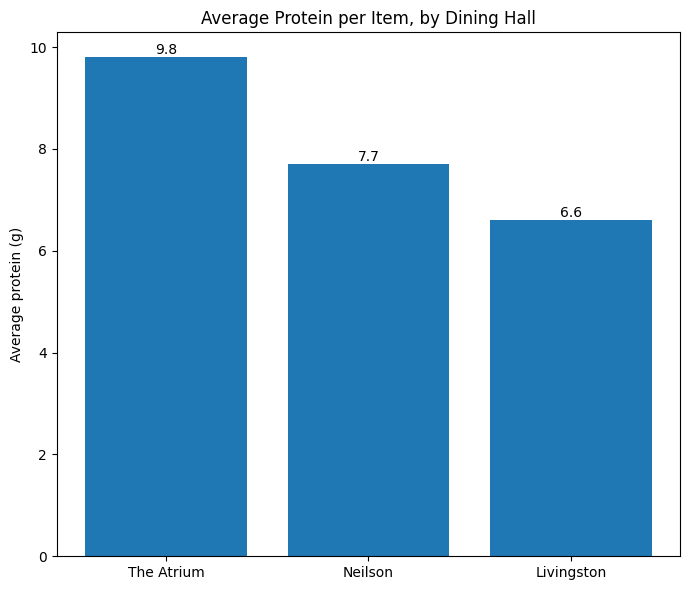

In [48]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(avg_prot_by_hall["hall_name"], avg_prot_by_hall["avg_protein_g"])
ax.set_ylabel("Average protein (g)")
ax.set_title("Average Protein per Item, by Dining Hall")
for i, v in enumerate(avg_prot_by_hall["avg_protein_g"]):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_avg_protein.png", dpi=150)
plt.show()


### 8.3 Calories vs. protein scatter (with high-protein cutoff)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sub = clean_df.dropna(subset=["calories_kcal", "protein_g"])
for hall in sub["dining_hall"].unique():
    h = sub[sub["dining_hall"] == hall]
    ax.scatter(h["calories_kcal"], h["protein_g"], alpha=0.5, label=hall, s=20)
ax.axhline(20, linestyle="--", linewidth=1, color="grey")
ax.axvline(600, linestyle="--", linewidth=1, color="grey")
ax.set_xlabel("Calories (kcal)")
ax.set_ylabel("Protein (g)")
ax.set_title("Calories vs. Protein -- dashed lines mark 'high protein under 600 kcal")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_cal_vs_protein.png", dpi=150)
plt.show()


### 8.4 Sodium distribution by dining hall (boxplot)

/tmp/ipykernel_3697799/459046870.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=True)


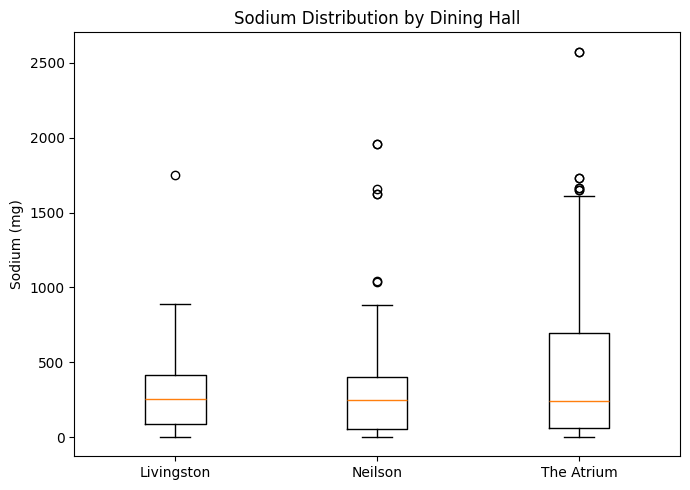

In [50]:
fig, ax = plt.subplots(figsize=(7, 5))
data, labels = [], []
for hall, group in clean_df.groupby("dining_hall"):
    vals = group["sodium_mg"].dropna()
    if len(vals):
        data.append(vals)
        labels.append(hall)
ax.boxplot(data, labels=labels, showfliers=True)
ax.set_ylabel("Sodium (mg)")
ax.set_title("Sodium Distribution by Dining Hall")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_sodium_box.png", dpi=150)
plt.show()


### 8.5 Top 10 high-protein items overall (horizontal bar)

In [ ]:
print("top_protein rows:", len(top_protein))
print("distinct (hall, item) pairs:",
      top_protein[["hall_name", "item_name"]].drop_duplicates().shape[0])

top10 = (top_protein
         .sort_values("protein_g", ascending=False)
         .drop_duplicates(subset=["hall_name", "item_name"])
         .head(10)
         .iloc[::-1]              
         .reset_index(drop=True))

labels = top10["item_name"].str.slice(0, 38) + " (" + top10["hall_name"] + ")"
y_pos  = range(len(top10))       

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(y_pos, top10["protein_g"])
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels)
ax.set_xlabel("Protein (g)")
ax.set_title(f"Top {len(top10)} High-Protein Menu Items")
for i, v in enumerate(top10["protein_g"]):
    ax.text(v, i, f" {v:.0f}g", va="center")
plt.tight_layout()
plt.savefig(DATA_DIR / "fig_top_protein.png", dpi=150)
plt.show()


## 9. Rule-based recommendation system

A transparent scoring function ranks foods by a student-chosen goal.
There is no black-box model -- every score is a closed-form combination
of the cleaned numeric fields, which makes the recommendations explainable.

Goals supported: `high_protein`, `low_calorie`, `low_sodium`, `balanced`.


In [52]:
def recommend(df: pd.DataFrame, goal: str = "high_protein", top_n: int = 10,
              meal: str | None = None, hall: str | None = None,
              vegetarian: bool = False, vegan: bool = False) -> pd.DataFrame:
    """Return ``top_n`` items ranked by ``goal``, with optional filters."""
    sub = df.dropna(subset=["calories_kcal"]).copy()

    if meal:        sub = sub[sub["meal_period"] == meal]
    if hall:        sub = sub[sub["dining_hall"] == hall]
    if vegetarian:  sub = sub[sub["is_vegetarian"]]
    if vegan:       sub = sub[sub["is_vegan"]]

    # protein density: protein per 100 kcal -- robust to serving size
    sub["protein_density"] = sub["protein_g"] / (sub["calories_kcal"] / 100).replace(0, np.nan)

    if goal == "high_protein":
        sub = sub.dropna(subset=["protein_g"])
        sub["score"] = sub["protein_density"]
    elif goal == "low_calorie":
        sub["score"] = -sub["calories_kcal"]
    elif goal == "low_sodium":
        sub = sub.dropna(subset=["sodium_mg"])
        sub["score"] = -sub["sodium_mg"]
    elif goal == "balanced":
        # reward protein, penalize calories and sodium (each on their own scale)
        prot = sub["protein_g"].fillna(0)
        cal  = sub["calories_kcal"].fillna(sub["calories_kcal"].median())
        sod  = sub["sodium_mg"].fillna(sub["sodium_mg"].median())
        sub["score"] = (prot / 5) - (cal / 200) - (sod / 800)
    else:
        raise ValueError(f"unknown goal: {goal!r}")

    cols = ["dining_hall", "meal_period", "item_name", "calories_kcal",
            "protein_g", "sodium_mg", "score"]
    return (sub.sort_values("score", ascending=False)
              .head(top_n)[cols]
              .reset_index(drop=True))


# Example: top 10 high-protein lunch options
recommend(clean_df, goal="high_protein", meal="Lunch", top_n=10)


,dining_hall,meal_period,item_name,calories_kcal,protein_g,sodium_mg,score
0,Neilson,Lunch,EGG WHITES,53.0,11.1,179.2,20.943396
1,The Atrium,Lunch,GRILLED CHICKEN BREAST,131.0,25.3,99.4,19.312977
2,The Atrium,Lunch,CHICKEN SOUVLAKI,320.0,58.0,1140.0,18.125000
3,Livingston,Lunch,GRILLED CHICKEN BREAST 4OZ,142.0,25.4,124.8,17.887324
4,The Atrium,Lunch,BAJA SHRIMP,134.0,23.5,177.8,17.537313
5,The Atrium,Lunch,GRILLED HALAL CHICKEN,157.0,26.3,77.0,16.751592
6,Neilson,Lunch,GRILLED CHICKEN MONTREAL,156.0,25.3,124.6,16.217949
7,Neilson,Lunch,ROTISSERIE STYLE CHICKEN,421.0,63.4,320.9,15.059382
8,Neilson,Lunch,SLICED MUSHROOMS,12.0,1.8,2.8,15.000000
9,The Atrium,Lunch,SLICED MUSHROOMS,12.0,1.8,2.8,15.000000


In [21]:
# A few more goal examples
print("\n--- low_calorie (any meal) ---")
print(recommend(clean_df, goal="low_calorie",  top_n=5).to_string(index=False))

print("\n--- low_sodium dinner ---")
print(recommend(clean_df, goal="low_sodium",  meal="Dinner", top_n=5).to_string(index=False))

print("\n--- balanced vegetarian ---")
print(recommend(clean_df, goal="balanced",    vegetarian=True, top_n=5).to_string(index=False))



--- low_calorie (any meal) ---
dining_hall meal_period             item_name  calories_kcal  protein_g  sodium_mg  score
 Livingston       Lunch     MONGOLIAN STATION            0.0        0.0        0.0   -0.0
 Livingston       Lunch         PASTA STATION            0.0        0.0        0.0   -0.0
 The Atrium       Lunch FRANK'S BUFFALO SAUCE            0.0        0.0     1612.8   -0.0
 Livingston       Lunch              TACO BAR            0.0        0.0        0.0   -0.0
 Livingston      Dinner         PASTA STATION            0.0        0.0        0.0   -0.0

--- low_sodium dinner ---
dining_hall meal_period            item_name  calories_kcal  protein_g  sodium_mg  score
 The Atrium      Dinner         AVOCADO MASH          125.0        1.1        0.0   -0.0
 Livingston      Dinner         AVOCADO MASH          125.0        1.1        0.0   -0.0
 The Atrium      Dinner CANNED BAMBOO SHOOTS            3.0        0.2        0.0   -0.0
    Neilson      Dinner          TACO SHELLS 

## 10. Evaluation

The proposal commits to five evaluation metrics. Each is implemented
below as a concrete check whose output the report can quote.


### 10.1 Scrape accuracy (manual spot-check stub)

In [53]:
# Pick five items at random and print their nutrition_link.
# In the report, manually open each link and compare with the row.
sample = clean_df[clean_df["nutrition_link"].notna()].sample(
    n=min(5, clean_df["nutrition_link"].notna().sum()),
    random_state=42,
)[["dining_hall", "meal_period", "item_name", "calories_kcal", "protein_g",
   "sodium_mg", "nutrition_link"]]
sample


,dining_hall,meal_period,item_name,calories_kcal,protein_g,sodium_mg,nutrition_link
153,Neilson,Breakfast,VEGAN EGG,176.0,12.6,403.2,https://menuportal23.dining.rutgers.edu/FoodPr...
118,Livingston,Dinner,BUTTER CHICKEN WITH CREAMY TOMATO SAUCE,189.0,12.5,344.9,https://menuportal23.dining.rutgers.edu/FoodPr...
245,Neilson,Dinner,SALSA,21.0,0.0,330.7,https://menuportal23.dining.rutgers.edu/FoodPr...
408,The Atrium,Lunch,SOURDOUGH BREAD,223.0,8.0,541.1,https://menuportal23.dining.rutgers.edu/FoodPr...
278,Neilson,Dinner,BAKED HALF POTATO W TRUFFLE OIL,194.0,2.8,563.9,https://menuportal23.dining.rutgers.edu/FoodPr...


### 10.2 Data completeness

In [54]:
total = len(clean_df)
print(f"Total menu items captured: {total}")
print()
print("Per-hall item counts:")
print(clean_df.groupby("dining_hall").size().to_string())
print()
print("Nutrition-field presence rate (%):")
print(completeness.to_string())


Total menu items captured: 575

Per-hall item counts:
dining_hall
Livingston    129
Neilson       155
The Atrium    291

Nutrition-field presence rate (%):
calories_kcal    99.8
total_fat_g      99.8
sat_fat_g        98.8
sodium_mg        99.7
total_carbs_g     0.0
fiber_g          97.9
sugar_g          96.9
protein_g        99.8


### 10.3 Data freshness

In [55]:
print("Scrape timestamp:", raw["scrape_timestamp"])
print("Scrape date     :", raw["scrape_date"])


Scrape timestamp: 2026-05-07T18:01:57
Scrape date     : 05/07/2026


### 10.4 Query/filter correctness

In [56]:
# Re-derive a query result two ways (SQL vs pandas) and check they agree.
sql_result = pd.read_sql_query(
    """SELECT h.hall_name, ROUND(AVG(n.calories_kcal), 2) AS avg_cal
         FROM menu_items m
         JOIN dining_halls h ON m.hall_id=h.hall_id
         JOIN nutrition_facts n ON m.item_id=n.item_id
        WHERE n.calories_kcal IS NOT NULL
        GROUP BY h.hall_name
        ORDER BY h.hall_name""", con)

pandas_result = (clean_df.dropna(subset=["calories_kcal"])
                          .groupby("dining_hall")["calories_kcal"]
                          .mean().round(2)
                          .reset_index()
                          .rename(columns={"dining_hall": "hall_name",
                                           "calories_kcal": "avg_cal"})
                          .sort_values("hall_name")
                          .reset_index(drop=True))

print("SQL:");    print(sql_result.to_string(index=False))
print("\nPandas:"); print(pandas_result.to_string(index=False))
print("\nMatch?", np.allclose(sql_result["avg_cal"], pandas_result["avg_cal"]))


SQL:
 hall_name  avg_cal
Livingston   134.88
   Neilson   147.11
The Atrium   202.06

Pandas:
 hall_name  avg_cal
Livingston   134.88
   Neilson   147.11
The Atrium   202.06

Match? True


### 10.5 Recommendation quality

In [57]:
# Verify each recommended item actually meets the constraint claimed by its goal.
def check_quality(df: pd.DataFrame, goal: str, predicate, top_n: int = 10) -> float:
    recs = recommend(df, goal=goal, top_n=top_n)
    if recs.empty:
        return float("nan")
    return predicate(recs).mean()


checks = {
    "high_protein -> protein_g >= 20":
        check_quality(clean_df, "high_protein", lambda d: d["protein_g"] >= 20),
    "low_calorie  -> calories  <= 400":
        check_quality(clean_df, "low_calorie",  lambda d: d["calories_kcal"] <= 400),
    "low_sodium   -> sodium    <= 600":
        check_quality(clean_df, "low_sodium",   lambda d: d["sodium_mg"] <= 600),
}
for k, v in checks.items():
    print(f"{k:<40s}  pass-rate: {v:.0%}")


high_protein -> protein_g >= 20           pass-rate: 70%
low_calorie  -> calories  <= 400          pass-rate: 100%
low_sodium   -> sodium    <= 600          pass-rate: 100%


## 11. Wrap-up

* Raw scrape: `output.json`
* Flat clean dataset: `data/menu_items_flat.csv`
* Database: `data/dining.db`  (5 tables)
* Figures: `data/fig_*.png`

These five outputs plus this notebook are the complete deliverable.


In [58]:
con.close()